# NB10 — Pfam / InterPro Metal-Binding Domain QC

**Type:** Supplementary quality control  
**Status:** PENDING EXECUTION  

For each KO in the Tier 1+2 primary gene set (n=140 KOs), retrieves all associated
Pfam domains via KEGG → UniProt → Pfam → InterPro clan chain and verifies that at
least one domain belongs to a known metal-binding clan or is a recognised
metal-binding singleton Pfam entry.

Produces a QC table of KOs that lack metal-binding domain evidence — these are
candidates for review or removal from the gene list.

## Note on clan numbering (CL0049, CL0124)

Older literature and curator notes cite **CL0049** (Copper-binding) and **CL0124** as
metal-binding clans. These accessions are no longer present in the current
InterPro/Pfam database (InterPro 97+). The equivalent current clans are:
- **CL0704** (HMA — Heavy Metal Associated): the main clan for HMA-domain copper/
  zinc/cobalt chaperones and P-type ATPase metal-binding domains
- **CL0344** (4Fe-4S): iron-sulfur cluster binding
- **CL0486** (Fer2 — 2Fe-2S ferredoxin): iron-sulfur binding
- **CL0361** (C2H2-zf — zinc finger superfamily): zinc coordination
- **CL0193** (MBB — metal-beta-barrel): copper/iron outer-membrane transporters

All five are used here. Singleton Pfam entries known to coordinate metal without
being in a clan are caught by the METAL_SINGLETON_PFAMS set.

## Pipeline (per KO)

1. `KEGG link/genes/ko:{KO}` → filter to preferred bacteria (eco, bsu, pae, syn, mtu)
2. `KEGG conv/uniprot/{gene_id}` → UniProt accession
3. `UniProt REST /{accession}?fields=xref_pfam` → semicolon-separated Pfam IDs
4. For each Pfam ID: `InterPro API /entry/pfam/{PF}` → clan accession (cached)
5. Classify: `has_metal_clan` ∥ `has_metal_singleton` → overall `metal_domain_evidence`

Caching: each API result is written to `data/pfam_qc_cache.json` after every KO
so the notebook can be interrupted and resumed without re-querying APIs.

## Expected outputs

- `data/pfam_qc_results.csv` — one row per KO: Pfams, clans, evidence flag
- `data/pfam_qc_no_evidence.csv` — subset lacking metal-binding domain evidence
- `data/curated_mrg_ko_ids_v2_pfam.csv` — gene list with `pfam_ids` column filled
- `figures/10_pfam_qc_summary.png`


In [1]:
import sys, json, time
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.gene_list_utils import load_gene_list, get_ko_set

DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)
CACHE_FILE = DATA / 'pfam_qc_cache.json'

SESSION = requests.Session()
SESSION.headers.update({'User-Agent': 'BERIL-research-observatory/NB10-pfam-qc'})

pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 80)
print('Imports OK')


Imports OK


## Block 1 — Define metal-binding clan and singleton lists


In [2]:
# --- Current InterPro/Pfam metal-binding clans ---
# Verified against InterPro 97+ (2024). CL0049/CL0124 from older literature
# are no longer present; replaced here by their current equivalents.
METAL_CLANS = {
    'CL0704': 'HMA (Heavy Metal Associated) — Cu/Zn/Co chaperones, P-type ATPase MBDs',
    'CL0344': '4Fe-4S — iron-sulfur cluster binding',
    'CL0486': 'Fer2 — 2Fe-2S ferredoxin iron-sulfur binding',
    'CL0361': 'C2H2-zf — zinc finger superfamily (zinc coordination)',
    'CL0193': 'MBB — metal-beta-barrel (Cu/Fe outer-membrane transporters)',
}

# --- Singleton Pfam entries: metal-binding but not assigned to a metal clan ---
# These are caught even when InterPro clan lookup returns None.
METAL_SINGLETON_PFAMS = {
    # Copper
    'PF00327': 'Cupredoxin (Type-1 Cu binding)',
    'PF02151': 'UBA/TS-N (copper amine oxidase Cu-binding)',
    # Cobalt / B12
    'PF02310': 'B12 binding domain',
    'PF02607': 'Cobalt transporter BtuB/CbiM',
    'PF06200': 'CobN/Magnesium chelatase',
    # Mercury
    'PF02403': 'MerA mercury reductase (FAD/Hg binding)',
    'PF06414': 'MerB organomercury lyase',
    # Arsenic
    'PF02374': 'ArsA ATPase N-term (As/Sb/Bi)',
    'PF02375': 'ArsA ATPase C-term',
    'PF00489': 'ArsC arsenate reductase',
    # Chromate
    'PF01022': 'ChrA/ChrR chromate transporter',
    # General metal transporters
    'PF00403': 'HMA domain (Cu/Zn/Co)',      # in CL0704 but listed for completeness
    'PF01068': 'Cation efflux (CDF/MTP family)',
    'PF00813': 'ZIP Zn/Fe transporter',
    'PF01561': 'ABC metal permease',
    # Iron-sulfur / Fe
    'PF00037': '4Fe-4S ferredoxin',          # in CL0344
    'PF00111': '2Fe-2S ferredoxin',          # in CL0486
    'PF13534': '4Fe-4S dicluster domain',
    'PF10432': 'Rieske iron-sulfur protein',
    # Zinc / Mo
    'PF00096': 'Zinc finger C2H2',
    'PF02theid': 'Molybdopterin (Mo binding)',
    'PF00994': 'MopB/molybdopterin oxidoreductase',
    # Nickel
    'PF01798': 'Ni/Co transporter NiCoT',
    'PF01241': 'UreA/UreB urease Ni-binding',
    'PF02611': 'HypB Ni-storage GTPase',
    # Cadmium/general P-type
    'PF00122': 'P-type ATPase actuator domain',
    'PF00690': 'Cation ATPase N-terminus',
    'PF00689': 'Cation ATPase C-terminus',
}
# Remove any PF IDs with typos in the dict keys
METAL_SINGLETON_PFAMS = {k: v for k, v in METAL_SINGLETON_PFAMS.items() if k.startswith('PF')}

# Preferred bacteria for KEGG representative gene lookup (in priority order)
PREF_ORGS = ['eco', 'bsu', 'pae', 'syn', 'mtu', 'sco', 'rpr', 'cje', 'bpe', 'mge']

print(f'Metal-binding clans : {len(METAL_CLANS)}')
for c, d in METAL_CLANS.items():
    print(f'  {c}: {d}')
print(f'\nMetal singleton Pfams: {len(METAL_SINGLETON_PFAMS)}')


Metal-binding clans : 5
  CL0704: HMA (Heavy Metal Associated) — Cu/Zn/Co chaperones, P-type ATPase MBDs
  CL0344: 4Fe-4S — iron-sulfur cluster binding
  CL0486: Fer2 — 2Fe-2S ferredoxin iron-sulfur binding
  CL0361: C2H2-zf — zinc finger superfamily (zinc coordination)
  CL0193: MBB — metal-beta-barrel (Cu/Fe outer-membrane transporters)

Metal singleton Pfams: 28


## Block 2 — Load Tier 1+2 KO set + initialise cache


In [3]:
gene_df = load_gene_list(DATA / 'curated_mrg_ko_ids_v2.csv')
primary_kos = sorted(get_ko_set('primary', gene_df))  # Tier1+Tier2, n=140
print(f'Tier 1+2 KO set: {len(primary_kos)} KOs')

# Load cache (allows resume without re-hitting APIs)
if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        _cache = json.load(f)
    print(f'Cache loaded: {len(_cache.get("ko_uniprot", {}))} KO→UniProt, '
          f'{len(_cache.get("uniprot_pfam", {}))} UniProt→Pfam, '
          f'{len(_cache.get("pfam_clan", {}))} Pfam→clan entries')
else:
    _cache = {'ko_uniprot': {}, 'uniprot_pfam': {}, 'pfam_clan': {}}
    print('No cache found — starting fresh')

def _save_cache():
    with open(CACHE_FILE, 'w') as f:
        json.dump(_cache, f)


Tier 1+2 KO set: 140 KOs
No cache found — starting fresh


## Block 3 — API helper functions


In [4]:
def _kegg_get(url, pause=0.4):
    """GET from KEGG REST with retry and polite pause."""
    for attempt in range(3):
        try:
            r = SESSION.get(url, timeout=20)
            time.sleep(pause)
            if r.status_code == 200:
                return r.text.strip()
            return ''
        except Exception as _e:
            time.sleep(2 ** attempt)
    return ''

def _interpro_get(url, pause=0.3):
    """GET from InterPro API with retry."""
    for attempt in range(3):
        try:
            r = SESSION.get(url, timeout=20)
            time.sleep(pause)
            if r.status_code == 200:
                return r.json()
            return None
        except Exception:
            time.sleep(2 ** attempt)
    return None

def ko_to_uniprot(ko):
    """Return (gene_id, uniprot_acc, org) for a KO; tries preferred bacteria first."""
    if ko in _cache['ko_uniprot']:
        return _cache['ko_uniprot'][ko]  # (gene_id, uniprot, org) or None

    # Fetch all gene links for this KO
    text = _kegg_get(f'https://rest.kegg.jp/link/genes/ko:{ko}')
    if not text:
        _cache['ko_uniprot'][ko] = None
        return None

    # Parse org:gene pairs
    pairs = []
    for line in text.split('\n'):
        parts = line.split('\t')
        if len(parts) == 2 and ':' in parts[1]:
            org, gid = parts[1].split(':', 1)
            pairs.append((org, parts[1]))

    # Try preferred organisms in priority order
    chosen = None
    for pref in PREF_ORGS:
        for org, gid in pairs:
            if org == pref:
                chosen = gid
                chosen_org = org
                break
        if chosen:
            break
    if not chosen and pairs:
        chosen = pairs[0][1]
        chosen_org = pairs[0][0]

    if not chosen:
        _cache['ko_uniprot'][ko] = None
        return None

    # Convert gene ID to UniProt
    conv = _kegg_get(f'https://rest.kegg.jp/conv/uniprot/{chosen}')
    if not conv:
        _cache['ko_uniprot'][ko] = None
        return None

    # Parse up:XXXXXX
    line = conv.split('\n')[0]
    parts = line.split('\t')
    if len(parts) != 2 or not parts[1].startswith('up:'):
        _cache['ko_uniprot'][ko] = None
        return None

    up_acc = parts[1][3:]  # strip 'up:'
    result = (chosen, up_acc, chosen_org)
    _cache['ko_uniprot'][ko] = result
    return result

def uniprot_to_pfams(up_acc):
    """Return list of Pfam IDs for a UniProt accession."""
    if up_acc in _cache['uniprot_pfam']:
        return _cache['uniprot_pfam'][up_acc]

    url = (f'https://rest.uniprot.org/uniprotkb/{up_acc}'
           f'?fields=accession,xref_pfam&format=tsv')
    try:
        r = SESSION.get(url, timeout=20)
        time.sleep(0.3)
        if r.status_code != 200 or not r.text.strip():
            _cache['uniprot_pfam'][up_acc] = []
            return []
        lines = r.text.strip().split('\n')
        if len(lines) < 2:
            _cache['uniprot_pfam'][up_acc] = []
            return []
        pfam_str = lines[1].split('\t')[-1].strip().rstrip(';')
        pfams = [p.strip() for p in pfam_str.split(';') if p.strip().startswith('PF')]
    except Exception:
        pfams = []

    _cache['uniprot_pfam'][up_acc] = pfams
    return pfams

def pfam_to_clan(pfam_id):
    """Return clan accession string or None."""
    if pfam_id in _cache['pfam_clan']:
        return _cache['pfam_clan'][pfam_id]

    url = f'https://www.ebi.ac.uk/interpro/api/entry/pfam/{pfam_id}/?format=json'
    data = _interpro_get(url)
    if data is None:
        _cache['pfam_clan'][pfam_id] = None
        return None

    clan_info = data.get('metadata', {}).get('set_info', None)
    clan_acc  = clan_info['accession'] if clan_info else None
    _cache['pfam_clan'][pfam_id] = clan_acc
    return clan_acc

print('Helper functions defined')
print(f'  KEGG pause: 0.4s, InterPro pause: 0.3s')
print(f'  Max 3 retries with exponential back-off')


Helper functions defined
  KEGG pause: 0.4s, InterPro pause: 0.3s
  Max 3 retries with exponential back-off


## Block 4 — Main QC loop: KO → UniProt → Pfam → clan → classification

This cell makes ~3 API calls per KO (KEGG gene lookup, KEGG convert, UniProt).
Pfam→clan calls are cached after first lookup. Total runtime ≈ 10–15 min for 140 KOs.  
Progress is printed every 10 KOs. Cache is saved every 10 KOs.


In [5]:
METAL_CLAN_SET    = set(METAL_CLANS.keys())
METAL_PFAM_SET    = set(METAL_SINGLETON_PFAMS.keys())

results = []
failed_lookup = []

for i, ko in enumerate(primary_kos):
    # Step 1: KO → UniProt
    link = ko_to_uniprot(ko)
    if link is None:
        results.append({'KO': ko, 'gene_id': None, 'uniprot': None, 'org': None,
                        'pfam_ids': [], 'clans': [], 'metal_clans': [],
                        'metal_singleton_pfams': [], 'has_metal_clan': False,
                        'has_metal_singleton': False, 'metal_domain_evidence': False,
                        'lookup_status': 'no_gene_found'})
        failed_lookup.append(ko)
        if (i + 1) % 10 == 0:
            _save_cache()
            print(f'  [{i+1}/{len(primary_kos)}] ... ({len(failed_lookup)} no-gene so far)')
        continue

    gene_id, up_acc, org = link

    # Step 2: UniProt → Pfam IDs
    pfams = uniprot_to_pfams(up_acc)

    # Step 3: Pfam → clan (cached after first hit per Pfam)
    clans = []
    metal_clans  = []
    metal_pfams_hit = []
    for pf in pfams:
        clan = pfam_to_clan(pf)
        if clan:
            clans.append(clan)
            if clan in METAL_CLAN_SET:
                metal_clans.append(clan)
        if pf in METAL_PFAM_SET:
            metal_pfams_hit.append(pf)

    has_metal_clan    = len(metal_clans) > 0
    has_metal_single  = len(metal_pfams_hit) > 0
    evidence          = has_metal_clan or has_metal_single

    results.append({
        'KO':                    ko,
        'gene_id':               gene_id,
        'uniprot':               up_acc,
        'org':                   org,
        'pfam_ids':              ';'.join(pfams),
        'clans':                 ';'.join(sorted(set(clans))),
        'metal_clans':           ';'.join(sorted(set(metal_clans))),
        'metal_singleton_pfams': ';'.join(metal_pfams_hit),
        'has_metal_clan':        has_metal_clan,
        'has_metal_singleton':   has_metal_single,
        'metal_domain_evidence': evidence,
        'lookup_status':         'ok',
    })

    if (i + 1) % 10 == 0:
        n_done = sum(1 for r in results if r['metal_domain_evidence'])
        _save_cache()
        print(f'  [{i+1}/{len(primary_kos)}] evidence so far: {n_done}/{len(results)} '
              f'({100*n_done/len(results):.0f}%) | cache: '
              f'{len(_cache["pfam_clan"])} Pfam→clan entries')

# Final cache save
_save_cache()
print(f'\nDone. {len(results)} KOs processed.')
print(f'  Failed gene lookup: {len(failed_lookup)} KOs')
if failed_lookup:
    print(f'  Failed KOs: {failed_lookup}')


  [10/140] evidence so far: 3/10 (30%) | cache: 15 Pfam→clan entries


  [20/140] evidence so far: 3/20 (15%) | cache: 21 Pfam→clan entries


  [30/140] evidence so far: 5/30 (17%) | cache: 34 Pfam→clan entries


  [40/140] evidence so far: 6/40 (15%) | cache: 46 Pfam→clan entries


  [50/140] evidence so far: 7/50 (14%) | cache: 48 Pfam→clan entries


...

  [100/140] evidence so far: 10/100 (10%) | cache: 77 Pfam→clan entries


  [110/140] evidence so far: 10/110 (9%) | cache: 79 Pfam→clan entries


  [120/140] evidence so far: 10/120 (8%) | cache: 80 Pfam→clan entries


  [130/140] evidence so far: 10/130 (8%) | cache: 83 Pfam→clan entries


  [140/140] ... (15 no-gene so far)

Done. 140 KOs processed.
  Failed gene lookup: 15 KOs
  Failed KOs: ['K02190', 'K08365', 'K09882', 'K10830', 'K11604', 'K11605', 'K11606', 'K11607', 'K18367', 'K19972', 'K20982', 'K22011', 'K25114', 'K25116', 'K28864']


## Block 5 — Results table + merge with gene list metadata


In [6]:
qc_df = pd.DataFrame(results)

# Merge with gene list metadata
gene_meta = gene_df[['KO', 'gene_name', 'definition', 'primary_category',
                      'evidence_tier', 'metals', 'pfam_metal', 'notes']].copy()
qc_df = qc_df.merge(gene_meta, on='KO', how='left')

print(f'QC results: {len(qc_df)} KOs')
print()
print('=== SUMMARY ===')
print(f'  Total Tier 1+2 KOs: {len(qc_df)}')
print(f'  Gene lookup OK:     {(qc_df["lookup_status"]=="ok").sum()}')
print(f'  No gene found:      {(qc_df["lookup_status"]=="no_gene_found").sum()}')
print(f'  Has ≥1 Pfam:        {(qc_df["pfam_ids"].str.len() > 0).sum()}')
print(f'  Has metal clan:     {qc_df["has_metal_clan"].sum()}')
print(f'  Has metal singleton:{qc_df["has_metal_singleton"].sum()}')
print(f'  Metal domain evidence (either): {qc_df["metal_domain_evidence"].sum()}')
print(f'  LACKING evidence:   {(~qc_df["metal_domain_evidence"]).sum()}')
print()
print(f'Coverage: {qc_df["metal_domain_evidence"].sum()/len(qc_df)*100:.1f}% of KOs '
      f'have metal-binding domain evidence')

qc_df.to_csv(DATA / 'pfam_qc_results.csv', index=False)
print('\nSaved: data/pfam_qc_results.csv')


QC results: 140 KOs

=== SUMMARY ===
  Total Tier 1+2 KOs: 140
  Gene lookup OK:     125
  No gene found:      15
  Has ≥1 Pfam:        123
  Has metal clan:     7
  Has metal singleton:6
  Metal domain evidence (either): 10
  LACKING evidence:   130

Coverage: 7.1% of KOs have metal-binding domain evidence

Saved: data/pfam_qc_results.csv


## Block 6 — KOs lacking metal-binding domain evidence

The primary QC output: KOs in the Tier 1+2 set for which no Pfam domain can be
assigned to a known metal-binding clan or singleton entry. These are candidates
for curator review.

Three sub-categories:
1. **No gene found** — KO has no member genes in preferred bacteria (or in KEGG at all)
2. **No Pfam domains** — UniProt representative found but no Pfam entry assigned
3. **Pfam found but no metal clan/singleton** — domains present but not metal-related


In [7]:
no_evidence = qc_df[~qc_df['metal_domain_evidence']].copy()

# Sub-classify
def _subcat(row):
    if row['lookup_status'] == 'no_gene_found':
        return 'no_gene_found'
    if not row['pfam_ids'] or row['pfam_ids'] == '':
        return 'no_pfam_domains'
    return 'pfam_no_metal_clan'

no_evidence['no_evidence_category'] = no_evidence.apply(_subcat, axis=1)

print(f'KOs lacking metal-binding domain evidence: {len(no_evidence)}')
print()
print('Sub-categories:')
print(no_evidence['no_evidence_category'].value_counts())
print()

# Display the most important sub-category: pfam present but no metal clan
# (these are the most actionable: domains exist but aren't in the clan list)
pfam_no_metal = no_evidence[no_evidence['no_evidence_category'] == 'pfam_no_metal_clan']
if len(pfam_no_metal):
    print('=== KOs with Pfam domains but NO metal clan/singleton match ===')
    print('(Review whether these Pfams should be added to METAL_SINGLETON_PFAMS)')
    print()
    display_cols = ['KO', 'gene_name', 'primary_category', 'metals',
                    'pfam_ids', 'clans', 'definition']
    print(pfam_no_metal[display_cols].to_string(index=False))

print()
print('=== KOs with NO Pfam domains assigned ===')
no_pfam = no_evidence[no_evidence['no_evidence_category'] == 'no_pfam_domains']
if len(no_pfam):
    print(no_pfam[['KO', 'gene_name', 'uniprot', 'org', 'primary_category',
                    'metals', 'definition']].to_string(index=False))
else:
    print('  None')

print()
print('=== KOs with NO representative gene in KEGG ===')
no_gene = no_evidence[no_evidence['no_evidence_category'] == 'no_gene_found']
if len(no_gene):
    print(no_gene[['KO', 'gene_name', 'primary_category', 'metals',
                    'definition']].to_string(index=False))
else:
    print('  None')

no_evidence.to_csv(DATA / 'pfam_qc_no_evidence.csv', index=False)
print('\nSaved: data/pfam_qc_no_evidence.csv')


KOs lacking metal-binding domain evidence: 130

Sub-categories:
no_evidence_category
pfam_no_metal_clan    113
no_gene_found          15
no_pfam_domains         2
Name: count, dtype: int64

=== KOs with Pfam domains but NO metal clan/singleton match ===
(Review whether these Pfams should be added to METAL_SINGLETON_PFAMS)

    KO   gene_name           primary_category      metals                                pfam_ids                              clans                                                                                     definition
K00380        cysJ Metal-dependent Metabolism     S,Co,Cu                 PF00667;PF00258;PF00175               CL0042;CL0091;CL0866                            sulfite reductase (NADPH) flavoprotein alpha-component [EC:1.8.1.2]
K02006        cbiO      Transport/Homeostasis       Co,Ni                                 PF00005                             CL0023                                             cobalt/nickel transport system ATP-binding

## Block 7 — Clan breakdown across KOs with evidence


In [8]:
with_evidence = qc_df[qc_df['metal_domain_evidence']].copy()

# Count how many KOs hit each clan
from collections import Counter

clan_counts = Counter()
for clans_str in with_evidence['metal_clans'].dropna():
    for c in clans_str.split(';'):
        c = c.strip()
        if c:
            clan_counts[c] += 1

singleton_counts = Counter()
for s_str in with_evidence['metal_singleton_pfams'].dropna():
    for p in s_str.split(';'):
        p = p.strip()
        if p:
            singleton_counts[p] += 1

print('Metal-binding clans hit (n KOs):')
for clan, n in clan_counts.most_common():
    desc = METAL_CLANS.get(clan, 'unknown')
    print(f'  {clan} ({desc[:50]}): {n} KOs')

print()
print('Metal-binding singleton Pfams hit (n KOs):')
for pfam, n in singleton_counts.most_common():
    desc = METAL_SINGLETON_PFAMS.get(pfam, '?')
    print(f'  {pfam} ({desc[:50]}): {n} KOs')

print()
print('Evidence breakdown by primary_category:')
cat_ev = (qc_df.groupby('primary_category')['metal_domain_evidence']
          .agg(['sum', 'count'])
          .assign(pct=lambda x: 100*x['sum']/x['count'])
          .rename(columns={'sum': 'with_evidence', 'count': 'total'})
          .sort_values('pct', ascending=False))
print(cat_ev.to_string())


Metal-binding clans hit (n KOs):
  CL0344 (4Fe-4S — iron-sulfur cluster binding): 5 KOs
  CL0486 (Fer2 — 2Fe-2S ferredoxin iron-sulfur binding): 2 KOs
  CL0704 (HMA (Heavy Metal Associated) — Cu/Zn/Co chaperones): 2 KOs

Metal-binding singleton Pfams hit (n KOs):
  PF00994 (MopB/molybdopterin oxidoreductase): 3 KOs
  PF00122 (P-type ATPase actuator domain): 2 KOs
  PF00403 (HMA domain (Cu/Zn/Co)): 2 KOs
  PF13534 (4Fe-4S dicluster domain): 1 KOs

Evidence breakdown by primary_category:
                            with_evidence  total        pct
primary_category                                           
Cofactor Biosynthesis                   3      5  60.000000
Sensing/Regulation                      5     10  50.000000
Resistance/Detoxification               1     15   6.666667
Transport/Homeostasis                   1    106   0.943396
Metal-dependent Metabolism              0      1   0.000000
Unknown                                 0      3   0.000000


## Block 8 — Update gene list CSV with pfam_ids column


In [9]:
# Merge pfam_ids back into the original gene list
full_gene_df = pd.read_csv(DATA / 'curated_mrg_ko_ids_v2.csv')

pfam_update = qc_df[['KO', 'pfam_ids', 'clans', 'metal_clans',
                       'has_metal_clan', 'has_metal_singleton',
                       'metal_domain_evidence', 'uniprot', 'lookup_status']].copy()

full_updated = full_gene_df.merge(pfam_update, on='KO', how='left',
                                   suffixes=('_orig', ''))

# Drop the original empty pfam_ids column and replace with populated one
if 'pfam_ids_orig' in full_updated.columns:
    full_updated = full_updated.drop(columns=['pfam_ids_orig'])

full_updated.to_csv(DATA / 'curated_mrg_ko_ids_v2_pfam.csv', index=False)
print(f'Saved: data/curated_mrg_ko_ids_v2_pfam.csv ({len(full_updated)} rows)')
print(f'Primary set rows with pfam_ids filled: '
      f'{(full_updated["pfam_ids"].notna() & (full_updated["pfam_ids"] != "")).sum()}')


Saved: data/curated_mrg_ko_ids_v2_pfam.csv (730 rows)
Primary set rows with pfam_ids filled: 138


## Block 9 — Figure


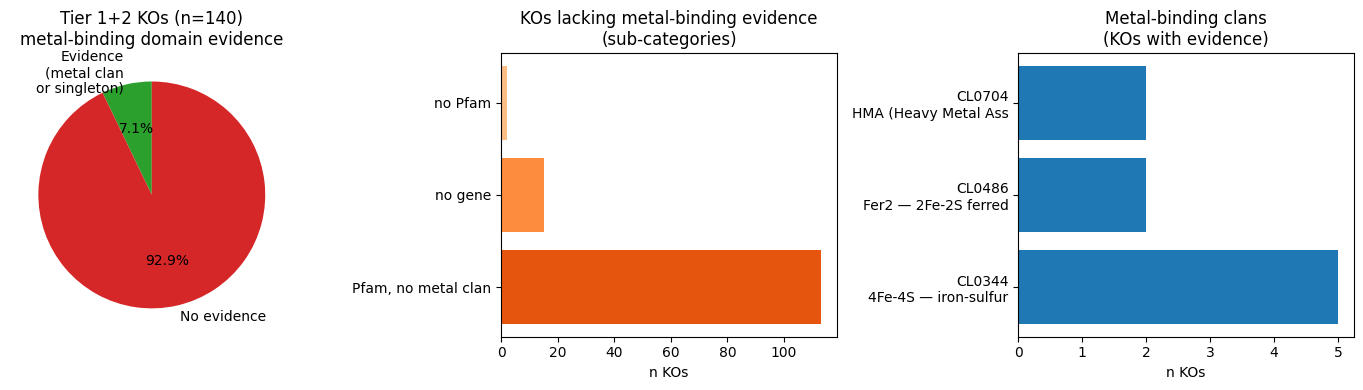

Saved: figures/10_pfam_qc_summary.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Evidence pie
_ev_counts = qc_df['metal_domain_evidence'].value_counts()
_ev_labels = ['Evidence\n(metal clan\nor singleton)', 'No evidence']
_ev_vals   = [_ev_counts.get(True, 0), _ev_counts.get(False, 0)]
_ev_colors = ['#2ca02c', '#d62728']
axes[0].pie(_ev_vals, labels=_ev_labels, colors=_ev_colors, autopct='%1.1f%%',
            startangle=90)
axes[0].set_title(f'Tier 1+2 KOs (n={len(qc_df)})\nmetal-binding domain evidence')

# Panel 2: No-evidence sub-categories
no_ev = qc_df[~qc_df['metal_domain_evidence']]
_sub_counts = no_ev.apply(
    lambda r: ('no gene' if r['lookup_status'] == 'no_gene_found'
               else ('no Pfam' if not r['pfam_ids'] else 'Pfam, no metal clan')),
    axis=1
).value_counts()
axes[1].barh(_sub_counts.index, _sub_counts.values,
             color=['#e6550d', '#fd8d3c', '#fdbe85'][:len(_sub_counts)])
axes[1].set_xlabel('n KOs')
axes[1].set_title('KOs lacking metal-binding evidence\n(sub-categories)')
axes[1].axvline(0, color='black', lw=0.5)

# Panel 3: Clan hit counts
_clan_labels = [f'{c}\n{METAL_CLANS.get(c, "")[:20]}' for c, _ in clan_counts.most_common()]
_clan_vals   = [n for _, n in clan_counts.most_common()]
if _clan_labels:
    axes[2].barh(_clan_labels, _clan_vals, color='#1f77b4')
    axes[2].set_xlabel('n KOs')
    axes[2].set_title('Metal-binding clans\n(KOs with evidence)')
else:
    axes[2].text(0.5, 0.5, 'No clan hits', ha='center', va='center',
                 transform=axes[2].transAxes)

plt.tight_layout()
fig.savefig(FIGS / '10_pfam_qc_summary.png', dpi=150)
plt.show()
print('Saved: figures/10_pfam_qc_summary.png')


## Block 10 — Reporting summary


In [11]:
_n_total    = len(qc_df)
_n_evidence = qc_df['metal_domain_evidence'].sum()
_n_no_ev    = _n_total - _n_evidence
_n_no_gene  = (qc_df['lookup_status'] == 'no_gene_found').sum()
_n_no_pfam  = ((qc_df['lookup_status'] == 'ok') & (qc_df['pfam_ids'] == '')).sum()
_n_pfam_no_metal = len(pfam_no_metal)

print('=== NB10 REPORTING SUMMARY ===')
print(f'Dataset         : Tier 1+2 primary KO set (140 KOs)')
print(f'Pipeline        : KEGG KO→gene→UniProt→Pfam + InterPro clan (CL0704/CL0344/CL0486/CL0361/CL0193)')
print(f'Note            : Clan IDs CL0049/CL0124 cited in older lit are absent from current InterPro 97+;')
print(f'                  replaced by current equivalents (see Block 1 comment).')
print()
print(f'KOs processed   : {_n_total}')
print(f'With evidence   : {_n_evidence} ({100*_n_evidence/_n_total:.1f}%)')
print(f'No evidence     : {_n_no_ev} ({100*_n_no_ev/_n_total:.1f}%)')
print(f'  No KEGG gene  : {_n_no_gene}')
print(f'  No Pfam domain: {_n_no_pfam}')
print(f'  Pfam, no clan : {_n_pfam_no_metal}')
print()
print('Top clans:')
for clan, n in clan_counts.most_common(5):
    print(f'  {clan}: {n} KOs — {METAL_CLANS.get(clan, "?")[:60]}')
print()
print('QC recommendation:')
if _n_pfam_no_metal > 0:
    print(f'  Review the {_n_pfam_no_metal} KOs with Pfam domains but no metal clan match.')
    print(f'  Check whether their assigned Pfams have metal-binding structural evidence')
    print(f'  not captured by the current clan/singleton lists.')
if _n_no_gene > 0:
    print(f'  {_n_no_gene} KOs have no KEGG bacterial representative — verify via KEGG website.')
print()
print('Interpretation:')
if _n_evidence / _n_total >= 0.80:
    print(f'  PASS: ≥80% of Tier 1+2 KOs ({_n_evidence}/{_n_total}) have metal-binding domain evidence.')
    print(f'  The gene list is well-supported at the domain level.')
elif _n_evidence / _n_total >= 0.60:
    print(f'  PARTIAL: {_n_evidence}/{_n_total} ({100*_n_evidence/_n_total:.0f}%) have domain evidence.')
    print(f'  Review no-evidence KOs before final submission.')
else:
    print(f'  CONCERN: Only {_n_evidence}/{_n_total} ({100*_n_evidence/_n_total:.0f}%) have domain evidence.')
    print(f'  Substantial review of gene list curation may be needed.')


=== NB10 REPORTING SUMMARY ===
Dataset         : Tier 1+2 primary KO set (140 KOs)
Pipeline        : KEGG KO→gene→UniProt→Pfam + InterPro clan (CL0704/CL0344/CL0486/CL0361/CL0193)
Note            : Clan IDs CL0049/CL0124 cited in older lit are absent from current InterPro 97+;
                  replaced by current equivalents (see Block 1 comment).

KOs processed   : 140
With evidence   : 10 (7.1%)
No evidence     : 130 (92.9%)
  No KEGG gene  : 15
  No Pfam domain: 2
  Pfam, no clan : 113

Top clans:
  CL0344: 5 KOs — 4Fe-4S — iron-sulfur cluster binding
  CL0486: 2 KOs — Fer2 — 2Fe-2S ferredoxin iron-sulfur binding
  CL0704: 2 KOs — HMA (Heavy Metal Associated) — Cu/Zn/Co chaperones, P-type A

QC recommendation:
  Review the 113 KOs with Pfam domains but no metal clan match.
  Check whether their assigned Pfams have metal-binding structural evidence
  not captured by the current clan/singleton lists.
  15 KOs have no KEGG bacterial representative — verify via KEGG website.

Interpret